In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)
df.info()


c:\Users\BAJWA LAPTOPS\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [ ]:
df_DA_USA= df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

df_DA_USA= df_DA_USA.dropna(subset=['salary_year_avg'])

In [5]:
df_DA_USA[['salary_year_avg']].sample(10)

,salary_year_avg
763081,60000.0
72328,80000.0
752471,113800.0
771421,70000.0
220300,56250.0
350559,72500.0
525710,110000.0
566095,67818.0
205476,70000.0
723163,127000.0


<Axes: >

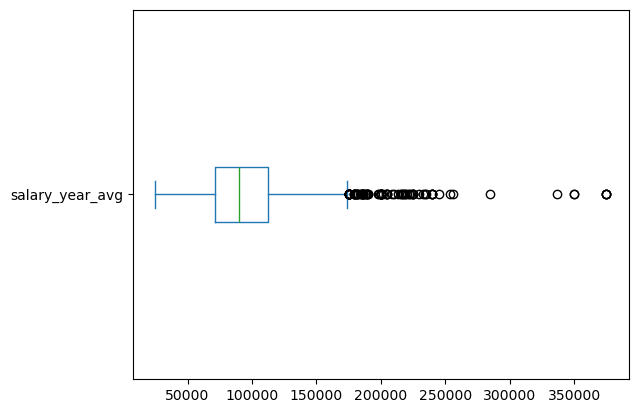

In [6]:
df_DA_USA.plot(kind='box', y='salary_year_avg', vert=False)

C:\Users\BAJWA LAPTOPS\AppData\Local\Temp\ipykernel_20068\3048920741.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_DA_USA['salary_year_avg'], labels=['Data Analyst Yearly Salary'], vert=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x1993d0673d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1993d070890>,
 'boxes': [<matplotlib.lines.Line2D at 0x1993d066a50>],
 'medians': [<matplotlib.lines.Line2D at 0x1993d071d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1993d072510>],
 'means': []}

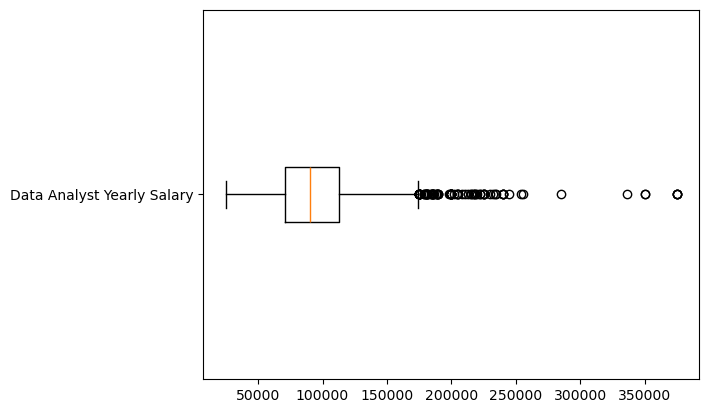

In [15]:
plt.boxplot(df_DA_USA['salary_year_avg'], labels=['Data Analyst Yearly Salary'], vert=False)

C:\Users\BAJWA LAPTOPS\AppData\Local\Temp\ipykernel_20068\4123010656.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


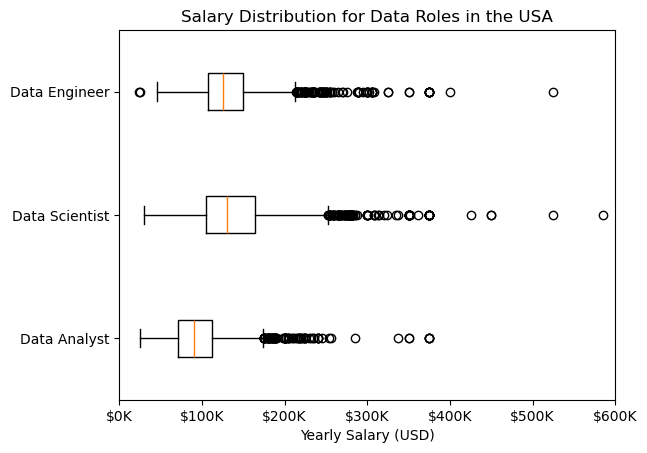

In [20]:
from matplotlib.ticker import FuncFormatter
job_titles= ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_US= df[df['job_title_short'].isin(job_titles) & (df['job_country']=='United States')].copy()

df_US= df_US.dropna(subset=['salary_year_avg'])

job_list= [df_US[df_US['job_title_short']==job]['salary_year_avg'] for job in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title("Salary Distribution for Data Roles in the USA")
plt.xlabel("Yearly Salary (USD)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
plt.xlim(0, 600000)
plt.show()